# **6. Modelo Propuesto: CBAM-UNet++ con FiLM Conditioning por Plano Anatómico**

En esta sección se implementa, entrena y evalúa el modelo original propuesto: **CBAM-UNet++ con FiLM Conditioning**, una arquitectura que integra tres mecanismos sobre una base UNet++ con encoder ResNet‑34 preentrenado en ImageNet:

1. **Decoder UNet++** – skip connections densamente anidadas que fusionan características de múltiples niveles de profundidad de forma gradual, mejorando la segmentación de lesiones con tamaños muy variables (meningiomas grandes vs. pituitarios pequeños).
2. **CBAM en las ramas del encoder** – módulos de atención secuencial canal‑espacial aplicados sobre los mapas de características de cada etapa del encoder antes de que se conecten al decoder. Esto permite recalibrar *qué* características son relevantes (canal) y *dónde* se localizan (espacial) en las representaciones que alimentan la reconstrucción.
3. **FiLM (Feature‑wise Linear Modulation) condicionado por plano anatómico** – el índice del plano (axial, coronal, sagital) se inyecta en el modelo mediante capas FiLM que aplican una modulación afín aprendida sobre los mapas de características del encoder, permitiendo que la red se adapte de forma suave a las diferencias de contraste, morfología y relación tumor/fondo detectadas en el EDA entre planos.

**Justificación empírica (a partir del EDA y benchmarks):**

- El análisis exploratorio (Sección 3.5) mostró diferencias significativas de intensidad media entre planos (Axial 0.147, Sagittal 0.190) y en la proporción de fondo negro (Axial 53.4 %, Sagittal 35.4 %). El *plane_idx* está disponible en los metadatos pero ningún modelo del benchmark lo utilizó.
- El benchmark reveló que todos los modelos sufren un rendimiento más bajo en Gliomas (≈68 % mIoU), que se caracterizan por bordes infiltrantes difusos. CBAM, que ya ha sido validado en tumores cerebrales [PKN26], puede ayudar a suprimir activaciones de fondo irrelevantes y refinar los bordes.
- UNet++ fue el segundo mejor modelo del benchmark (80.85 % Weighted mIoU), estadísticamente equivalente a U‑Net pero con mejor IoU en Meningiomas y una fusión multi‑escala más robusta para distintos tamaños tumorales.

**Comparabilidad experimental garantizada:**  
Se utilizan exactamente los mismos splits (CSV), el mismo pipeline de preprocesamiento, la misma función de pérdida (ComboLoss 0.5·Dice + 0.5·BCE), los mismos hiperparámetros de optimización, el mismo encoder base (ResNet‑34 preentrenado) y la misma semilla (42) que en el notebook de benchmarks.

---

## 6.1 Configuración del Entorno

In [1]:
from google.colab import drive
drive.mount('/content/drive')

!pip install -q segmentation-models-pytorch==0.5.0
!pip install -q albumentations==1.4.0

import os
import gc
import re
import time
import copy
import json
import math
import random
import zipfile
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.amp import GradScaler, autocast
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp
from collections import defaultdict

from scipy import stats
from scipy.stats import friedmanchisquare, wilcoxon

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True

print("=" * 70)
print("CONFIGURACIÓN DEL ENTORNO — MODELO PROPUESTO CBAM-UNet++ + FiLM")
print("=" * 70)
print(f"PyTorch:     {torch.__version__}")
print(f"SMP:         {smp.__version__}")
print(f"Device:      {device}")
if torch.cuda.is_available():
    print(f"GPU:         {torch.cuda.get_device_name(0)}")
    print(f"VRAM total:  {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
print(f"Seed:        {SEED}")
print("=" * 70)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CONFIGURACIÓN DEL ENTORNO — MODELO PROPUESTO CBAM-UNet++ + FiLM
PyTorch:     2.10.0+cu128
SMP:         0.5.0
Device:      cuda
GPU:         NVIDIA A100-SXM4-40GB
VRAM total:  39.5 GB
Seed:        42


## 6.2 Configuración Global y Parámetros

In [2]:
IMG_SIZE    = 512
BATCH_SIZE  = 64
NUM_WORKERS = 8 if torch.cuda.is_available() else 4
PIN_MEMORY  = torch.cuda.is_available()

HPARAMS = {
    'max_epochs': 500,
    'patience': 80,
    'learning_rate': 2e-4,
    'weight_decay': 1e-4,
    'scheduler_patience': 20,
    'scheduler_factor': 0.5,
    'min_lr': 1e-7,
    'grad_clip': 1.0,
}

print("=" * 70)
print("CONFIGURACIÓN GLOBAL — MODELO PROPUESTO CBAM-UNet++ + FiLM")
print("=" * 70)
print(f"  IMG_SIZE:    {IMG_SIZE}×{IMG_SIZE}")
print(f"  BATCH_SIZE:  {BATCH_SIZE}")
print(f"  NUM_WORKERS: {NUM_WORKERS}")
print(f"  PIN_MEMORY:  {PIN_MEMORY}")
print("\nHiperparámetros de entrenamiento:")
for k, v in HPARAMS.items():
    print(f"  {k}: {v}")
print("=" * 70)


CONFIGURACIÓN GLOBAL — MODELO PROPUESTO CBAM-UNet++ + FiLM
  IMG_SIZE:    512×512
  BATCH_SIZE:  64
  NUM_WORKERS: 8
  PIN_MEMORY:  True

Hiperparámetros de entrenamiento:
  max_epochs: 500
  patience: 80
  learning_rate: 0.0002
  weight_decay: 0.0001
  scheduler_patience: 20
  scheduler_factor: 0.5
  min_lr: 1e-07
  grad_clip: 1.0



## 6.3 Carga de Datos y DataLoaders


In [3]:
DRIVE_ROOT   = "/content/drive/MyDrive/tumores_ceb_proyecto_modelo original_propuesto_1"
SPLITS_DIR   = os.path.join(DRIVE_ROOT, "splits")
CKPT_DIR     = os.path.join(DRIVE_ROOT, "checkpoints_proposed_v2")
RESULTS_DIR  = os.path.join(DRIVE_ROOT, "results_proposed_v2")
FIGURES_DIR  = os.path.join(DRIVE_ROOT, "figures_proposed_v2")
COLAB_DATA   = "/content/brisc2025"
ZIP_PATH     = os.path.join(DRIVE_ROOT, "brisc2025.zip")

for d in [CKPT_DIR, RESULTS_DIR, FIGURES_DIR]:
    os.makedirs(d, exist_ok=True)

if not os.path.exists(COLAB_DATA):
    print("Descomprimiendo dataset...")
    t0 = time.time()
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall("/content/")
    print(f"Completado en {(time.time()-t0)/60:.2f} min")
else:
    print(f"Dataset disponible en {COLAB_DATA}")

PLANE_TO_IDX = {'Axial': 0, 'Coronal': 1, 'Sagittal': 2}

df_train = pd.read_csv(os.path.join(SPLITS_DIR, 'split_train.csv'))
df_val   = pd.read_csv(os.path.join(SPLITS_DIR, 'split_val.csv'))
df_test  = pd.read_csv(os.path.join(SPLITS_DIR, 'split_test.csv'))

print("\nSplits cargados (idénticos a los benchmarks):")
print(f"  Train: {len(df_train)}")
print(f"  Val:   {len(df_val)}")
print(f"  Test:  {len(df_test)}")

class BRISCSegDataset(Dataset):
    def __init__(self, dataframe, transforms=None):
        self.df = dataframe.reset_index(drop=True)
        self.transforms = transforms

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image = np.array(Image.open(row['image_path']).convert('L'), dtype=np.float32) / 255.0
        mask  = np.array(Image.open(row['mask_path']).convert('L'), dtype=np.float32) / 255.0
        mask  = (mask > 0.5).astype(np.float32)

        if self.transforms:
            transformed = self.transforms(image=image, mask=mask)
            image = transformed['image']
            mask  = transformed['mask']
        else:
            image = torch.from_numpy(image).float()
            mask  = torch.from_numpy(mask).float()

        image = image.float().clamp(0.0, 1.0)
        mask  = (mask > 0.5).float()

        if image.ndim == 2:
            image = image.unsqueeze(0)
        if mask.ndim == 2:
            mask = mask.unsqueeze(0)

        meta = {
            'filename': row['filename'],
            'tumor_label': row['tumor_label'],
            'plane_label': row['plane_label'],
            'plane_idx': torch.tensor(PLANE_TO_IDX.get(row['plane_label'], 0), dtype=torch.long),
        }
        return image, mask, meta

train_transforms = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE, interpolation=2),
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.03, scale_limit=0.05, rotate_limit=10, border_mode=0, p=0.30),
    A.RandomBrightnessContrast(brightness_limit=0.10, contrast_limit=0.10, p=0.25),
    A.GaussNoise(var_limit=(3.0, 12.0), p=0.15),
    ToTensorV2(),
])

val_test_transforms = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE, interpolation=2),
    ToTensorV2(),
])

train_dataset = BRISCSegDataset(df_train, transforms=train_transforms)
val_dataset   = BRISCSegDataset(df_val,   transforms=val_test_transforms)
test_dataset  = BRISCSegDataset(df_test,  transforms=val_test_transforms)

_dl_kwargs = dict(
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=(NUM_WORKERS > 0),
)
if NUM_WORKERS > 0:
    _dl_kwargs["prefetch_factor"] = 4

train_loader = DataLoader(train_dataset, shuffle=True,  drop_last=True,  **_dl_kwargs)
val_loader   = DataLoader(val_dataset,   shuffle=False, drop_last=False, **_dl_kwargs)
test_loader  = DataLoader(test_dataset,  shuffle=False, drop_last=False, **_dl_kwargs)

print("\nDatasets y DataLoaders creados (réplica exacta de los benchmarks).")


Dataset disponible en /content/brisc2025

Splits cargados (idénticos a los benchmarks):
  Train: 3146
  Val:   787
  Test:  860

Datasets y DataLoaders creados (réplica exacta de los benchmarks).




## 6.4 Funciones de Pérdida y Métricas

In [4]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, pred, target):
        pred = torch.sigmoid(pred)
        pred_flat = pred.reshape(-1)
        target_flat = target.reshape(-1)
        intersection = (pred_flat * target_flat).sum()
        dice = (2.0 * intersection + self.smooth) / (pred_flat.sum() + target_flat.sum() + self.smooth)
        return 1.0 - dice

class ComboLoss(nn.Module):
    def __init__(self, alpha=0.5, smooth=1.0):
        super().__init__()
        self.alpha = alpha
        self.dice_loss = DiceLoss(smooth=smooth)
        self.bce_loss = nn.BCEWithLogitsLoss()

    def forward(self, pred, target):
        return self.alpha * self.dice_loss(pred, target) + (1 - self.alpha) * self.bce_loss(pred, target)

def compute_iou(pred, target, threshold=0.5, smooth=1e-6):
    pred_bin = (torch.sigmoid(pred) > threshold).float()
    intersection = (pred_bin * target).sum(dim=(1,2,3))
    union = pred_bin.sum(dim=(1,2,3)) + target.sum(dim=(1,2,3)) - intersection
    return (intersection + smooth) / (union + smooth)

def compute_dice(pred, target, threshold=0.5, smooth=1e-6):
    pred_bin = (torch.sigmoid(pred) > threshold).float()
    intersection = (pred_bin * target).sum(dim=(1,2,3))
    return (2.0 * intersection + smooth) / (pred_bin.sum(dim=(1,2,3)) + target.sum(dim=(1,2,3)) + smooth)



## 6.5 Motor de Entrenamiento

In [5]:
AMP_ENABLED = torch.cuda.is_available()
AMP_DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

def clear_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

def train_one_epoch(model, loader, criterion, optimizer, scaler, device, grad_clip=1.0):
    model.train()
    running_loss, running_iou, running_dice = 0.0, 0.0, 0.0
    n_batches = 0

    for images, masks, metas in loader:
        images = images.to(device, non_blocking=True)
        masks  = masks.to(device, non_blocking=True)
        plane_idx = metas['plane_idx'].to(device, non_blocking=True)  # para FiLM

        optimizer.zero_grad(set_to_none=True)

        with autocast(device_type=AMP_DEVICE, enabled=AMP_ENABLED):
            outputs = model(images, plane_idx)
            loss = criterion(outputs, masks)

        scaler.scale(loss).backward()
        if grad_clip is not None:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        scaler.step(optimizer)
        scaler.update()

        with torch.no_grad():
            running_loss += loss.item()
            running_iou  += compute_iou(outputs, masks).mean().item()
            running_dice += compute_dice(outputs, masks).mean().item()
            n_batches += 1

    return {'loss': running_loss/n_batches, 'iou': running_iou/n_batches, 'dice': running_dice/n_batches}

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, running_iou, running_dice = 0.0, 0.0, 0.0
    n_batches = 0

    for images, masks, metas in loader:
        images = images.to(device, non_blocking=True)
        masks  = masks.to(device, non_blocking=True)
        plane_idx = metas['plane_idx'].to(device, non_blocking=True)

        with autocast(device_type=AMP_DEVICE, enabled=AMP_ENABLED):
            outputs = model(images, plane_idx)
            loss = criterion(outputs, masks)

        running_loss += loss.item()
        running_iou  += compute_iou(outputs, masks).mean().item()
        running_dice += compute_dice(outputs, masks).mean().item()
        n_batches += 1

    return {'loss': running_loss/n_batches, 'iou': running_iou/n_batches, 'dice': running_dice/n_batches}

def train_model(model, model_name, train_loader, val_loader, device, hparams=HPARAMS):
    print(f"\n{'='*70}")
    print(f"ENTRENAMIENTO: {model_name}")
    print(f"{'='*70}")

    total_p = sum(p.numel() for p in model.parameters())
    trainable_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Parámetros totales:      {total_p:,}")
    print(f"Parámetros entrenables:  {trainable_p:,}")
    print(f"Tamaño estimado:         {total_p*4/1024**2:.1f} MB")

    model = model.to(device)
    criterion = ComboLoss(alpha=0.5)
    optimizer = optim.AdamW(model.parameters(), lr=hparams['learning_rate'], weight_decay=hparams['weight_decay'])
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=hparams['scheduler_factor'],
                                                     patience=hparams['scheduler_patience'], min_lr=hparams['min_lr'])
    scaler = GradScaler(device='cuda', enabled=AMP_ENABLED)

    history = {'train_loss':[], 'train_iou':[], 'train_dice':[],
               'val_loss':[],   'val_iou':[],   'val_dice':[], 'lr':[]}

    best_val_dice = -1.0
    best_model_state = None
    best_epoch = 0
    patience_counter = 0
    start_time = time.time()

    ckpt_path = os.path.join(CKPT_DIR, f'{model_name}_best.pth')

    for epoch in range(1, hparams['max_epochs']+1):
        epoch_start = time.time()

        train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, scaler, device, hparams['grad_clip'])
        val_metrics   = evaluate(model, val_loader, criterion, device)

        current_lr = optimizer.param_groups[0]['lr']
        scheduler.step(val_metrics['dice'])

        history['train_loss'].append(train_metrics['loss'])
        history['train_iou'].append(train_metrics['iou'])
        history['train_dice'].append(train_metrics['dice'])
        history['val_loss'].append(val_metrics['loss'])
        history['val_iou'].append(val_metrics['iou'])
        history['val_dice'].append(val_metrics['dice'])
        history['lr'].append(current_lr)

        improved = val_metrics['dice'] > best_val_dice
        if improved:
            best_val_dice = val_metrics['dice']
            best_model_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch
            patience_counter = 0
            marker = "BEST"
            torch.save({'epoch': epoch, 'model_state_dict': best_model_state,
                        'val_dice': best_val_dice, 'val_iou': val_metrics['iou'],
                        'history_length': len(history['train_loss']), 'hparams': hparams}, ckpt_path)
        else:
            patience_counter += 1
            marker = f"patience {patience_counter}/{hparams['patience']}"

        print(f"Epoch {epoch:03d}/{hparams['max_epochs']} | "
              f"Train Loss: {train_metrics['loss']:.4f} | Train IoU: {train_metrics['iou']:.4f} | Train Dice: {train_metrics['dice']:.4f} || "
              f"Val Loss: {val_metrics['loss']:.4f} | Val IoU: {val_metrics['iou']:.4f} | Val Dice: {val_metrics['dice']:.4f} | "
              f"LR: {current_lr:.2e} | {time.time()-epoch_start:.1f}s | {marker}")

        if patience_counter >= hparams['patience']:
            print(f"\nEarly Stopping activado en epoch {epoch}.")
            print(f"Mejor epoch: {best_epoch} | Mejor Val Dice: {best_val_dice:.4f}")
            break

    model.load_state_dict(best_model_state)

    safe_name = model_name.lower().replace(' ', '_').replace('+', 'plus')
    history_path = os.path.join(RESULTS_DIR, f'{safe_name}_history.json')
    with open(history_path, 'w') as f:
        json.dump(history, f, indent=2)

    total_time = time.time() - start_time
    print(f"\nResumen de entrenamiento — {model_name}")
    print("─" * 60)
    print(f"Mejor epoch:     {best_epoch}")
    print(f"Mejor Val Dice:  {best_val_dice:.4f}")
    print(f"Mejor Val IoU:   {history['val_iou'][best_epoch-1]:.4f}")
    print(f"Tiempo total:    {total_time/60:.1f} min")
    print(f"Checkpoint:      {ckpt_path}")
    print(f"Historial:       {history_path}")

    return model, history


## 6.6 Evaluación Detallada y Funciones de Visualización

In [6]:
@torch.no_grad()
def evaluate_detailed(model, loader, device, model_name="Model"):
    model.eval()
    all_results = []

    for images, masks, metas in loader:
        images = images.to(device, non_blocking=True)
        masks  = masks.to(device, non_blocking=True)
        plane_idx = metas['plane_idx'].to(device, non_blocking=True)

        with autocast(device_type=AMP_DEVICE, enabled=AMP_ENABLED):
            outputs = model(images, plane_idx)

        ious  = compute_iou(outputs, masks)
        dices = compute_dice(outputs, masks)

        for i in range(len(images)):
            all_results.append({
                'filename': metas['filename'][i],
                'tumor_label': metas['tumor_label'][i],
                'plane_label': metas['plane_label'][i],
                'iou': ious[i].item(),
                'dice': dices[i].item(),
            })

    results_df = pd.DataFrame(all_results)

    tumor_iou = results_df.groupby('tumor_label')['iou'].mean()
    tumor_counts = results_df.groupby('tumor_label')['iou'].count()
    weighted_miou = (tumor_iou * tumor_counts / tumor_counts.sum()).sum()

    plane_iou = results_df.groupby('plane_label')['iou'].mean()
    global_iou = results_df['iou'].mean()
    global_dice = results_df['dice'].mean()

    summary = {
        'model_name': model_name,
        'global_iou': global_iou,
        'global_dice': global_dice,
        'weighted_miou': weighted_miou,
        'tumor_iou': tumor_iou.to_dict(),
        'plane_iou': plane_iou.to_dict(),
        'cross_iou': results_df.groupby(['tumor_label','plane_label'])['iou'].mean().to_dict(),
        'tumor_dice': results_df.groupby('tumor_label')['dice'].mean().to_dict(),
        'plane_dice': results_df.groupby('plane_label')['dice'].mean().to_dict(),
    }

    print(f"\n{'='*70}")
    print(f"RESULTADOS EN TEST — {model_name}")
    print(f"{'='*70}")
    print(f"Weighted mIoU:  {weighted_miou*100:.2f}%")
    print(f"Global mIoU:    {global_iou*100:.2f}%")
    print(f"Global Dice:    {global_dice*100:.2f}%")

    print("\nmIoU por Tipo Tumoral:")
    for t in ['Glioma','Meningioma','Pituitary']:
        print(f"  {t:<15} {tumor_iou.get(t,0)*100:.2f}%")

    print("\nmIoU por Plano Anatómico:")
    for p in ['Axial','Coronal','Sagittal']:
        print(f"  {p:<15} {plane_iou.get(p,0)*100:.2f}%")

    cross_table = results_df.pivot_table(values='iou', index='tumor_label', columns='plane_label', aggfunc='mean')
    cross_table = cross_table.reindex(index=['Glioma','Meningioma','Pituitary'], columns=['Axial','Coronal','Sagittal']) * 100
    print("\nmIoU por Tumor × Plano:")
    print(cross_table.round(2).to_string())

    return results_df, summary

def save_model_results(model_name, model, history, test_loader, device):
    results_df, summary = evaluate_detailed(model, test_loader, device, model_name)
    safe_name = model_name.lower().replace(' ', '_').replace('+', 'plus')
    results_df.to_csv(os.path.join(RESULTS_DIR, f'{safe_name}_test_results.csv'), index=False)
    summary_serializable = {k: (v if not isinstance(v, dict) else {str(kk): vv for kk,vv in v.items()}) for k,v in summary.items()}
    with open(os.path.join(RESULTS_DIR, f'{safe_name}_summary.json'), 'w') as f:
        json.dump(summary_serializable, f, indent=2)
    print(f"Resultados guardados en {safe_name}_test_results.csv y {safe_name}_summary.json")
    return results_df, summary

def model_already_trained(model_name):
    safe_name = model_name.lower().replace(' ', '_').replace('+', 'plus')
    paths = [os.path.join(CKPT_DIR, f'{model_name}_best.pth'),
             os.path.join(RESULTS_DIR, f'{safe_name}_summary.json'),
             os.path.join(RESULTS_DIR, f'{safe_name}_history.json')]
    if all(os.path.exists(p) for p in paths):
        ck = torch.load(paths[0], map_location='cpu')
        print(f"  {model_name} encontrado — Val Dice: {ck['val_dice']:.4f} (epoch {ck['epoch']})")
        return True
    return False

def load_model_from_checkpoint(build_fn, model_name, device):
    model = build_fn()
    ckpt_path = os.path.join(CKPT_DIR, f'{model_name}_best.pth')
    ck = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(ck['model_state_dict'])
    model = model.to(device).eval()
    print(f"  {model_name} cargado (Val Dice: {ck['val_dice']:.4f})")
    return model

def load_saved_results(model_name):
    safe_name = model_name.lower().replace(' ', '_').replace('+', 'plus')
    with open(os.path.join(RESULTS_DIR, f'{safe_name}_history.json'), 'r') as f:
        history = json.load(f)
    with open(os.path.join(RESULTS_DIR, f'{safe_name}_summary.json'), 'r') as f:
        summary = json.load(f)
    results_df = pd.read_csv(os.path.join(RESULTS_DIR, f'{safe_name}_test_results.csv'))
    print(f"  Resultados cargados: {len(results_df)} imágenes, {len(history['train_loss'])} epochs")
    return history, summary, results_df

def plot_training_curves(history, model_name):
    fig, axes = plt.subplots(1, 3, figsize=(18,5))
    epochs = range(1, len(history['train_loss'])+1)
    for ax, tr, vl, lbl in zip(axes,
        ['train_loss','train_iou','train_dice'],
        ['val_loss','val_iou','val_dice'],
        ['Loss','IoU','Dice Score']):
        ax.plot(epochs, history[tr], label='Train')
        ax.plot(epochs, history[vl], label='Validation')
        ax.set_title(f'{model_name} — {lbl}')
        ax.legend(); ax.grid(alpha=0.3)
    plt.suptitle(f'Curvas de Entrenamiento — {model_name}', fontsize=14)
    plt.tight_layout()
    safe = model_name.lower().replace(' ', '_').replace('+', 'plus')
    plt.savefig(os.path.join(FIGURES_DIR, f'proposed_{safe}_curves.png'), dpi=150, bbox_inches='tight')
    plt.show()

@torch.no_grad()
def visualize_predictions(model, loader, device, model_name, n_samples=6):
    model.eval()
    images_list, masks_list, preds_list, metas_list = [], [], [], []
    for images, masks, metas in loader:
        plane_idx = metas['plane_idx'].to(device)
        with autocast(device_type=AMP_DEVICE, enabled=AMP_ENABLED):
            outputs = model(images.to(device), plane_idx)
        preds = (torch.sigmoid(outputs) > 0.5).float().cpu()
        for i in range(len(images)):
            images_list.append(images[i]); masks_list.append(masks[i]); preds_list.append(preds[i])
            metas_list.append({'tumor_label':metas['tumor_label'][i], 'plane_label':metas['plane_label'][i]})
        if len(images_list) >= n_samples: break
    n = min(n_samples, len(images_list))
    fig, axes = plt.subplots(n, 4, figsize=(16, n*3.5))
    if n==1: axes = np.expand_dims(axes,0)
    for i in range(n):
        img = np.clip(images_list[i][0].numpy(),0,1); gt = masks_list[i][0].numpy(); pr = preds_list[i][0].numpy()
        overlay = np.stack([img]*3, -1)
        tp = (gt==1)&(pr==1); fn=(gt==1)&(pr==0); fp=(gt==0)&(pr==1)
        overlay[tp]=[0,0.8,0]; overlay[fn]=[0.9,0,0]; overlay[fp]=[0,0.3,0.9]
        iou = tp.sum()/(tp.sum()+fn.sum()+fp.sum()+1e-6)
        axes[i,0].imshow(img, cmap='gray'); axes[i,0].set_title(metas_list[i]['tumor_label'][:3]+'/'+metas_list[i]['plane_label'][:3])
        axes[i,1].imshow(gt, cmap='gray'); axes[i,1].set_title('GT')
        axes[i,2].imshow(pr, cmap='gray'); axes[i,2].set_title('Pred')
        axes[i,3].imshow(np.clip(overlay,0,1)); axes[i,3].set_title(f'IoU {iou*100:.1f}%')
        for ax in axes[i]: ax.axis('off')
    fig.suptitle(f'Predicciones en Test — {model_name}', fontsize=14)
    plt.tight_layout()
    safe = model_name.lower().replace(' ', '_').replace('+', 'plus')
    plt.savefig(os.path.join(FIGURES_DIR, f'proposed_{safe}_predictions.png'), dpi=150, bbox_inches='tight')
    plt.show()

@torch.no_grad()
def visualize_best_worst(model, results_df, df_test_ref, device, model_name, n=5):
    model.eval()
    merged = results_df.merge(df_test_ref[['filename','image_path','mask_path']], on='filename', how='left')
    best = merged.nlargest(n, 'iou')
    worst = merged.nsmallest(n, 'iou')
    fig, axes = plt.subplots(2, n, figsize=(n*3.5,7))
    for row_idx, (subset, label) in enumerate([(best,'Mejores'),(worst,'Peores')]):
        for col_idx, (_, sample) in enumerate(subset.iterrows()):
            img = np.array(Image.open(sample['image_path']).convert('L'), dtype=np.float32)/255.0
            mask = np.array(Image.open(sample['mask_path']).convert('L'), dtype=np.float32)/255.0
            mask = (mask>0.5).astype(np.float32)
            transform = A.Compose([A.Resize(IMG_SIZE,IMG_SIZE,2), ToTensorV2()])
            res = transform(image=img, mask=mask)
            img_t = res['image'].clamp(0,1).unsqueeze(0).to(device)

            plane = PLANE_TO_IDX[sample['plane_label']]
            plane_t = torch.tensor([plane], device=device)
            with autocast(device_type=AMP_DEVICE, enabled=AMP_ENABLED):
                pred = (torch.sigmoid(model(img_t, plane_t)) > 0.5).float().cpu().squeeze().numpy()
            img_np = np.clip(res['image'].squeeze().numpy(),0,1)
            gt_np = res['mask'].numpy()
            overlay = np.stack([img_np]*3,-1)
            tp=(gt_np==1)&(pred==1); fn=(gt_np==1)&(pred==0); fp=(gt_np==0)&(pred==1)
            overlay[tp]=[0,0.8,0]; overlay[fn]=[0.9,0,0]; overlay[fp]=[0,0.3,0.9]
            axes[row_idx,col_idx].imshow(np.clip(overlay,0,1))
            axes[row_idx,col_idx].set_title(f"{sample['tumor_label'][:3]}/{sample['plane_label'][:3]}\nIoU {sample['iou']*100:.1f}%", fontsize=9)
            axes[row_idx,col_idx].axis('off')
    axes[0,0].set_ylabel('Mejores', fontsize=12, fontweight='bold')
    axes[1,0].set_ylabel('Peores', fontsize=12, fontweight='bold')
    fig.suptitle(f'Top {n} Mejores y Peores — {model_name}', fontsize=14)
    plt.tight_layout()
    safe = model_name.lower().replace(' ', '_').replace('+', 'plus')
    plt.savefig(os.path.join(FIGURES_DIR, f'proposed_{safe}_best_worst.png'), dpi=150, bbox_inches='tight')
    plt.show()

## 6.7 Definición de la Arquitectura Propuesta

### 6.7.1 Módulo CBAM

In [7]:
class CBAMChannelAttention(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        mid = max(channels // reduction, 4)
        self.mlp = nn.Sequential(
            nn.Conv2d(channels, mid, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(mid, channels, 1, bias=False),
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        return x * self.sigmoid(self.mlp(self.avg_pool(x)) + self.mlp(self.max_pool(x)))

class CBAMSpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=kernel_size//2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg = x.mean(dim=1, keepdim=True)
        mx, _ = x.max(dim=1, keepdim=True)
        return x * self.sigmoid(self.conv(torch.cat([avg, mx], dim=1)))

class CBAM(nn.Module):
    def __init__(self, channels, reduction=16, kernel_size=7):
        super().__init__()
        self.channel_att = CBAMChannelAttention(channels, reduction)
        self.spatial_att = CBAMSpatialAttention(kernel_size)

    def forward(self, x):
        return self.spatial_att(self.channel_att(x))



### 6.7.2 Capa FiLM

In [8]:

class FiLM(nn.Module):
    """Feature-wise Linear Modulation condicionada por el índice del plano."""
    def __init__(self, channels):
        super().__init__()
        self.gamma_fc = nn.Linear(3, channels)
        self.beta_fc  = nn.Linear(3, channels)

    def forward(self, x, plane_idx):

        plane_onehot = F.one_hot(plane_idx, num_classes=3).float()
        gamma = self.gamma_fc(plane_onehot).unsqueeze(-1).unsqueeze(-1)
        beta  = self.beta_fc(plane_onehot).unsqueeze(-1).unsqueeze(-1)
        return x * (1 + gamma) + beta


### 6.7.3 Encoder con CBAM + FiLM

In [9]:
class EncoderWithCBAMFiLM(nn.Module):
    """ResNet34 preentrenado que devuelve los features de cada etapa con CBAM + FiLM."""
    def __init__(self, in_channels=1):
        super().__init__()
        import torchvision.models as models
        resnet = models.resnet34(weights='IMAGENET1K_V1')
        self.conv1 = nn.Conv2d(in_channels, 64, 7, stride=2, padding=3, bias=False)
        with torch.no_grad():
            self.conv1.weight.copy_(resnet.conv1.weight.mean(dim=1, keepdim=True))
        self.bn1 = resnet.bn1
        self.relu = resnet.relu
        self.maxpool = resnet.maxpool
        self.layer1 = resnet.layer1
        self.layer2 = resnet.layer2
        self.layer3 = resnet.layer3
        self.layer4 = resnet.layer4

        self.cbam0 = CBAM(64)
        self.film0 = FiLM(64)
        self.cbam1 = CBAM(64)
        self.film1 = FiLM(64)
        self.cbam2 = CBAM(128)
        self.film2 = FiLM(128)
        self.cbam3 = CBAM(256)
        self.film3 = FiLM(256)
        self.cbam4 = CBAM(512)
        self.film4 = FiLM(512)

    def forward(self, x, plane_idx):
        # Stem
        x0 = self.relu(self.bn1(self.conv1(x)))
        x0 = self.cbam0(x0)
        x0 = self.film0(x0, plane_idx)

        xp = self.maxpool(x0)
        s1 = self.layer1(xp)
        s1 = self.cbam1(s1)
        s1 = self.film1(s1, plane_idx)

        s2 = self.layer2(s1)
        s2 = self.cbam2(s2)
        s2 = self.film2(s2, plane_idx)

        s3 = self.layer3(s2)
        s3 = self.cbam3(s3)
        s3 = self.film3(s3, plane_idx)

        bot = self.layer4(s3)
        bot = self.cbam4(bot)
        bot = self.film4(bot, plane_idx)
        return [x0, s1, s2, s3, bot]

In [10]:
class EncoderResNet34WithCBAM(nn.Module):
    """ResNet34 preentrenado + CBAM en cada etapa, sin modulación por plano."""
    def __init__(self, in_channels=1):
        super().__init__()
        import torchvision.models as models
        resnet = models.resnet34(weights='IMAGENET1K_V1')
        self.conv1 = nn.Conv2d(in_channels, 64, 7, stride=2, padding=3, bias=False)
        with torch.no_grad():
            self.conv1.weight.copy_(resnet.conv1.weight.mean(dim=1, keepdim=True))
        self.bn1 = resnet.bn1
        self.relu = resnet.relu
        self.maxpool = resnet.maxpool
        self.layer1 = resnet.layer1
        self.layer2 = resnet.layer2
        self.layer3 = resnet.layer3
        self.layer4 = resnet.layer4

        self.cbam0 = CBAM(64)
        self.cbam1 = CBAM(64)
        self.cbam2 = CBAM(128)
        self.cbam3 = CBAM(256)
        self.cbam4 = CBAM(512)

    def forward(self, x):
        x0 = self.relu(self.bn1(self.conv1(x)))
        x0 = self.cbam0(x0)

        xp = self.maxpool(x0)
        s1 = self.layer1(xp)
        s1 = self.cbam1(s1)

        s2 = self.layer2(s1)
        s2 = self.cbam2(s2)

        s3 = self.layer3(s2)
        s3 = self.cbam3(s3)

        bot = self.layer4(s3)
        bot = self.cbam4(bot)

        return [x0, s1, s2, s3, bot]


class EncoderResNet34WithFiLM(nn.Module):
    """ResNet34 preentrenado + FiLM en cada etapa, sin atención CBAM."""
    def __init__(self, in_channels=1):
        super().__init__()
        import torchvision.models as models
        resnet = models.resnet34(weights='IMAGENET1K_V1')
        self.conv1 = nn.Conv2d(in_channels, 64, 7, stride=2, padding=3, bias=False)
        with torch.no_grad():
            self.conv1.weight.copy_(resnet.conv1.weight.mean(dim=1, keepdim=True))
        self.bn1 = resnet.bn1
        self.relu = resnet.relu
        self.maxpool = resnet.maxpool
        self.layer1 = resnet.layer1
        self.layer2 = resnet.layer2
        self.layer3 = resnet.layer3
        self.layer4 = resnet.layer4

        self.film0 = FiLM(64)
        self.film1 = FiLM(64)
        self.film2 = FiLM(128)
        self.film3 = FiLM(256)
        self.film4 = FiLM(512)

    def forward(self, x, plane_idx):
        x0 = self.relu(self.bn1(self.conv1(x)))
        x0 = self.film0(x0, plane_idx)

        xp = self.maxpool(x0)
        s1 = self.layer1(xp)
        s1 = self.film1(s1, plane_idx)

        s2 = self.layer2(s1)
        s2 = self.film2(s2, plane_idx)

        s3 = self.layer3(s2)
        s3 = self.film3(s3, plane_idx)

        bot = self.layer4(s3)
        bot = self.film4(bot, plane_idx)

        return [x0, s1, s2, s3, bot]



### 6.7.4 Decoder UNet++ personalizado

Implementamos un decoder UNet++ con conexiones densas, similar al de la librería SMP, pero adaptado para recibir los cinco niveles de features y sin incluir deep supervision.


In [11]:
class UNetPlusPlusDecoder(nn.Module):
    """Decoder UNet++ con skip connections densas (versión ligera)."""
    def __init__(self, encoder_channels=[64,64,128,256,512], decoder_channels=[32,64,128,256,512]):
        super().__init__()
        self.num_levels = len(encoder_channels)  # 5

        self.blocks = nn.ModuleDict()
        for j in range(1, self.num_levels):
            for i in range(self.num_levels - j):
                in_ch = 0
                if j == 1:
                    in_ch += encoder_channels[i]
                else:
                    for k in range(1, j):
                        in_ch += decoder_channels[i]
                in_ch += decoder_channels[i+1]
                self.blocks[f"x_{i}_{j}"] = nn.Sequential(
                    nn.Conv2d(in_ch, decoder_channels[i], 3, padding=1, bias=False),
                    nn.BatchNorm2d(decoder_channels[i]),
                    nn.ReLU(inplace=True),
                    nn.Conv2d(decoder_channels[i], decoder_channels[i], 3, padding=1, bias=False),
                    nn.BatchNorm2d(decoder_channels[i]),
                    nn.ReLU(inplace=True),
                )

        self.final_upsample = nn.Sequential(
            nn.Conv2d(decoder_channels[0], decoder_channels[0], 3, padding=1, bias=False),
            nn.BatchNorm2d(decoder_channels[0]),
            nn.ReLU(inplace=True),
        )
        self.final_conv = nn.Conv2d(decoder_channels[0], 1, kernel_size=1)

    def forward(self, skips):
        X = [[None]*self.num_levels for _ in range(self.num_levels)]
        for i, skip in enumerate(skips):
            X[i][0] = skip

        for j in range(1, self.num_levels):
            for i in range(self.num_levels - j):
                inputs = []
                for k in range(1, j):
                    if X[i][k] is not None:
                        inputs.append(F.interpolate(X[i][k], size=X[i][0].shape[2:], mode='bilinear', align_corners=False))
                if X[i+1][j-1] is not None:
                    up = F.interpolate(X[i+1][j-1], size=X[i][0].shape[2:], mode='bilinear', align_corners=False)
                    inputs.append(up)
                if j == 1:
                    inputs.append(X[i][0])

                x_cat = torch.cat(inputs, dim=1)
                X[i][j] = self.blocks[f"x_{i}_{j}"](x_cat)

        out = X[0][self.num_levels-1]
        out = F.interpolate(out, scale_factor=2, mode='bilinear', align_corners=False)
        out = self.final_upsample(out)
        out = self.final_conv(out)
        return out


### 6.7.5 Modelo completo CBAM-UNet++ con FiLM

In [12]:

class CBAMUNetPlusPlusFiLM(nn.Module):
    def __init__(self, in_channels=1, num_classes=1):
        super().__init__()
        self.encoder = EncoderWithCBAMFiLM(in_channels)

        self.decoder = UNetPlusPlusDecoder(
            encoder_channels=[64, 64, 128, 256, 512],
            decoder_channels=[32, 64, 128, 256, 512]
        )

    def forward(self, x, plane_idx):
        skips = self.encoder(x, plane_idx)
        return self.decoder(skips)


### 6.7.6 Verificación de dimensiones

In [13]:
def build_cbam_unetplusplus_film():
    """Modelo completo: CBAM + FiLM + UNet++."""
    return CBAMUNetPlusPlusFiLM(in_channels=1, num_classes=1)


def build_cbam_unetplusplus_nofilm():
    """Ablación: CBAM + UNet++ sin FiLM."""
    class CBAMUNetPlusPlus_NoFiLM(nn.Module):
        def __init__(self):
            super().__init__()
            self.encoder = EncoderResNet34WithCBAM(in_channels=1)
            self.decoder = UNetPlusPlusDecoder(
                encoder_channels=[64, 64, 128, 256, 512],
                decoder_channels=[32, 64, 128, 256, 512]
            )

        def forward(self, x, plane_idx=None):

            skips = self.encoder(x)
            return self.decoder(skips)

    return CBAMUNetPlusPlus_NoFiLM()


def build_unetplusplus_film_only():
    """Ablación: FiLM + UNet++ sin CBAM."""
    class UNetPlusPlus_FiLMOnly(nn.Module):
        def __init__(self):
            super().__init__()
            self.encoder = EncoderResNet34WithFiLM(in_channels=1)
            self.decoder = UNetPlusPlusDecoder(
                encoder_channels=[64, 64, 128, 256, 512],
                decoder_channels=[32, 64, 128, 256, 512]
            )

        def forward(self, x, plane_idx):
            skips = self.encoder(x, plane_idx)
            return self.decoder(skips)

    return UNetPlusPlus_FiLMOnly()


print("=" * 70)
print("ARQUITECTURAS DEFINIDAS — CBAM-UNet++ con FiLM + ABLACIONES")
print("=" * 70)

for nombre, build_fn in [
    ("CBAM-UNet++ + FiLM (Completo)", build_cbam_unetplusplus_film),
    ("CBAM-UNet++ sin FiLM (Ablación)", build_cbam_unetplusplus_nofilm),
    ("UNet++ + FiLM sin CBAM (Ablación)", build_unetplusplus_film_only),
]:
    model = build_fn()
    params = sum(p.numel() for p in model.parameters())
    print(f"  {nombre:<42} | {params:,} params ({params*4/1024**2:.1f} MB)")
    del model

print("\nVerificación de dimensiones (forward pass 1×1×512×512):")
x_test = torch.randn(1, 1, 512, 512)
p_test = torch.tensor([1])

for nombre, build_fn in [
    ("CBAM-UNet++ + FiLM", build_cbam_unetplusplus_film),
    ("CBAM-UNet++ sin FiLM", build_cbam_unetplusplus_nofilm),
    ("UNet++ + FiLM", build_unetplusplus_film_only),
]:
    model = build_fn()
    try:
        if "sin FiLM" in nombre:
            out = model(x_test)
        else:
            out = model(x_test, p_test)
        ok = out.shape == (1, 1, 512, 512)
        print(f"  {'Si' if ok else 'No'} {nombre}: {x_test.shape} -> {out.shape}")
    except Exception as e:
        print(f"  No {nombre}: ERROR — {e}")
    del model

print("\n Verificación completada. Tres variantes listas para entrenamiento.")

ARQUITECTURAS DEFINIDAS — CBAM-UNet++ con FiLM + ABLACIONES
  CBAM-UNet++ + FiLM (Completo)              | 25,546,251 params (97.5 MB)
  CBAM-UNet++ sin FiLM (Ablación)            | 25,538,059 params (97.4 MB)
  UNet++ + FiLM sin CBAM (Ablación)          | 25,501,729 params (97.3 MB)

Verificación de dimensiones (forward pass 1×1×512×512):
  Si CBAM-UNet++ + FiLM: torch.Size([1, 1, 512, 512]) -> torch.Size([1, 1, 512, 512])
  Si CBAM-UNet++ sin FiLM: torch.Size([1, 1, 512, 512]) -> torch.Size([1, 1, 512, 512])
  Si UNet++ + FiLM: torch.Size([1, 1, 512, 512]) -> torch.Size([1, 1, 512, 512])

 Verificación completada. Tres variantes listas para entrenamiento.





## 6.8 Entrenamiento de los modelos

### CBAM-UNet++ con FiLM (MODELO COMPLETO)

INICIALIZACIÓN DE ALMACENAMIENTO DE RESULTADOS
  all_summaries: 8 modelos
  all_results:   3 modelos
  all_histories: 3 modelos
FASE 1: Entrenando modelo COMPLETO
Umbral requerido: 80.94% (mejor benchmark: U-Net)
  CBAM_UNetPlusPlus_FiLM encontrado — Val Dice: 0.8755 (epoch 183)

CBAM_UNetPlusPlus_FiLM ya entrenado. Cargando modelo y mostrando métricas...
  CBAM_UNetPlusPlus_FiLM cargado (Val Dice: 0.8755)
  Resultados cargados: 860 imágenes, 263 epochs

RESULTADOS EN TEST — CBAM_UNetPlusPlus_FiLM
Weighted mIoU:  80.98%
Global mIoU:    80.98%
Global Dice:    87.58%

mIoU por Tipo Tumoral:
  Glioma          68.98%
  Meningioma      90.49%
  Pituitary       81.43%

mIoU por Plano Anatómico:
  Axial           79.93%
  Coronal         80.48%
  Sagittal        82.88%

mIoU por Tumor × Plano:
plane_label  Axial  Coronal  Sagittal
tumor_label                          
Glioma       62.83    71.04     73.02
Meningioma   90.46    90.43     90.62
Pituitary    80.03    79.47     85.50
Resultados g

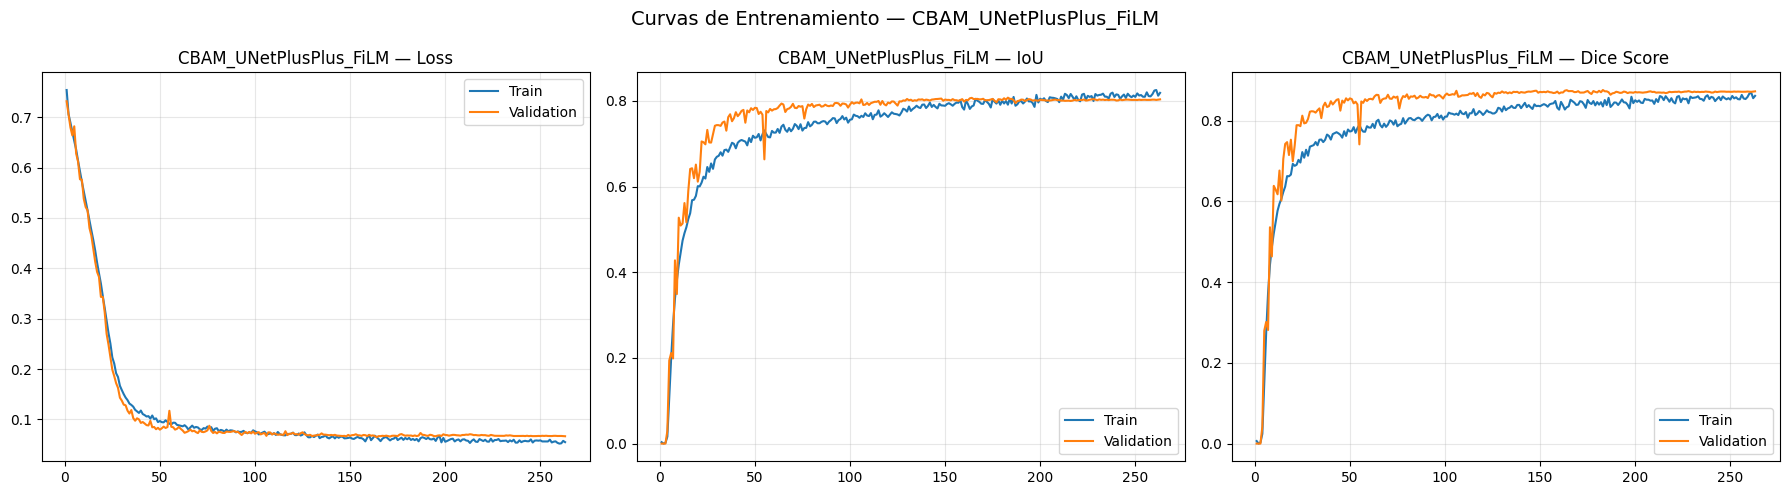


RESULTADO MODELO COMPLETO: 80.98%
Umbral (mejor benchmark): 80.94%

 COMPLETO SUPERA EL UMBRAL
   → Se entrenarán las variantes ablativas para medir aporte individual

CBAM_UNetPlusPlus_FiLM completado y guardado en Drive.


In [23]:

if 'all_summaries' not in dir():
    all_summaries = {}
if 'all_results' not in dir():
    all_results = {}
if 'all_histories' not in dir():
    all_histories = {}

BEST_BENCHMARK_WMIoU = 80.94

print("=" * 70)
print("INICIALIZACIÓN DE ALMACENAMIENTO DE RESULTADOS")
print("=" * 70)
print(f"  all_summaries: {len(all_summaries)} modelos")
print(f"  all_results:   {len(all_results)} modelos")
print(f"  all_histories: {len(all_histories)} modelos")
print("=" * 70)

_name = "CBAM_UNetPlusPlus_FiLM"
_build_fn = build_cbam_unetplusplus_film

print("=" * 70)
print(f"FASE 1: Entrenando modelo COMPLETO")
print(f"Umbral requerido: {BEST_BENCHMARK_WMIoU}% (mejor benchmark: U-Net)")
print("=" * 70)

if model_already_trained(_name):
    print(f"\n{_name} ya entrenado. Cargando modelo y mostrando métricas...")

    _model = load_model_from_checkpoint(_build_fn, _name, device)

    _history, _summary, _results_df = load_saved_results(_name)

    _results_df, _summary = save_model_results(
        model_name=_name,
        model=_model,
        history=_history,
        test_loader=test_loader,
        device=device
    )
    _full_wmiou = _summary['weighted_miou'] * 100
    plot_training_curves(_history, _name)

    del _model
    clear_memory()

else:
    clear_memory()
    _model = _build_fn()

    _model, _history = train_model(
        model=_model,
        model_name=_name,
        train_loader=train_loader,
        val_loader=val_loader,
        device=device,
        hparams=HPARAMS
    )

    plot_training_curves(_history, _name)

    _results_df, _summary = save_model_results(
        model_name=_name,
        model=_model,
        history=_history,
        test_loader=test_loader,
        device=device
    )

    visualize_predictions(
        model=_model,
        loader=test_loader,
        device=device,
        model_name=_name,
        n_samples=6
    )

    _full_wmiou = _summary['weighted_miou'] * 100

    del _model
    clear_memory()
    print(f"VRAM liberada después de {_name}")

all_summaries[_name] = _summary
all_results[_name]   = _results_df
all_histories[_name] = _history

print("\n" + "=" * 70)
print(f"RESULTADO MODELO COMPLETO: {_full_wmiou:.2f}%")
print(f"Umbral (mejor benchmark): {BEST_BENCHMARK_WMIoU:.2f}%")
print("=" * 70)

if _full_wmiou >= BEST_BENCHMARK_WMIoU:
    print(f"\n COMPLETO SUPERA EL UMBRAL")
    print(f"   → Se entrenarán las variantes ablativas para medir aporte individual")
    _train_ablations = True
else:
    print(f"\n COMPLETO NO SUPERA EL UMBRAL")
    print(f"   → No se entrenarán ablaciones (ahorro de tokens de cómputo)")
    _train_ablations = False

print(f"\n{_name} completado y guardado en Drive.")


### Ablación — CBAM-UNet++ SIN FiLM

FASE 2: Entrenando ablación — CBAM_UNetPlusPlus_NoFiLM
  CBAM_UNetPlusPlus_NoFiLM encontrado — Val Dice: 0.8795 (epoch 141)

CBAM_UNetPlusPlus_NoFiLM ya entrenado. Cargando modelo y mostrando métricas...
  CBAM_UNetPlusPlus_NoFiLM cargado (Val Dice: 0.8795)
  Resultados cargados: 860 imágenes, 221 epochs

RESULTADOS EN TEST — CBAM_UNetPlusPlus_NoFiLM
Weighted mIoU:  80.92%
Global mIoU:    80.92%
Global Dice:    87.44%

mIoU por Tipo Tumoral:
  Glioma          68.96%
  Meningioma      90.83%
  Pituitary       80.95%

mIoU por Plano Anatómico:
  Axial           79.54%
  Coronal         80.21%
  Sagittal        83.50%

mIoU por Tumor × Plano:
plane_label  Axial  Coronal  Sagittal
tumor_label                          
Glioma       61.58    70.73     74.45
Meningioma   91.02    90.36     91.00
Pituitary    79.16    79.05     85.53
Resultados guardados en cbam_unetplusplus_nofilm_test_results.csv y cbam_unetplusplus_nofilm_summary.json


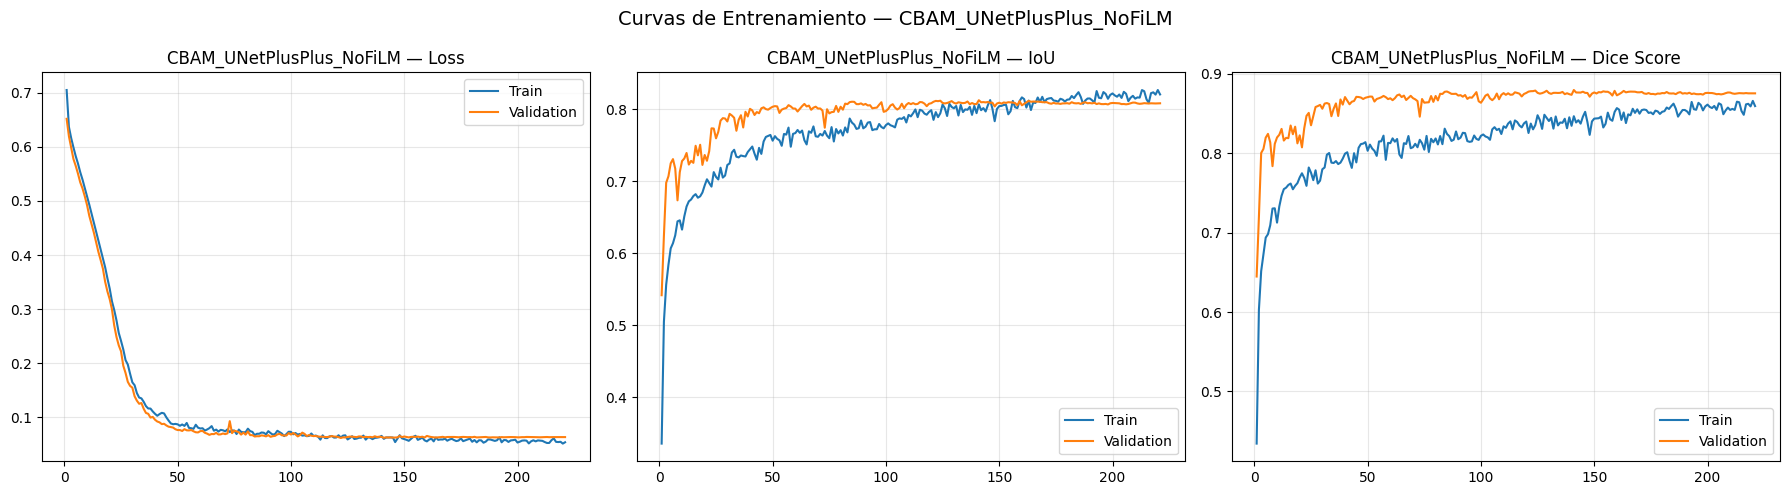


COMPARACIÓN DE ABLACIÓN — CBAM_UNetPlusPlus_NoFiLM
  CBAM_UNetPlusPlus_NoFiLM Weighted mIoU:           80.92%
  Modelo COMPLETO Weighted mIoU:   80.98%
  Diferencia (Completo - Ablación): +0.05 pp

CBAM_UNetPlusPlus_NoFiLM completado.


In [18]:

_name = "CBAM_UNetPlusPlus_NoFiLM"

_full_wmiou_ref = all_summaries.get('CBAM_UNetPlusPlus_FiLM', {}).get('weighted_miou', 0.8094) * 100

if not _train_ablations:
    print(f" Omitiendo {_name} — el modelo completo no superó el umbral.")
else:
    print("=" * 70)
    print(f"FASE 2: Entrenando ablación — {_name}")
    print("=" * 70)

    if model_already_trained(_name):
        print(f"\n{_name} ya entrenado. Cargando modelo y mostrando métricas...")
        _model = load_model_from_checkpoint(build_cbam_unetplusplus_nofilm, _name, device)
        _history, _summary, _results_df = load_saved_results(_name)
        _results_df, _summary = save_model_results(
            model_name=_name,
            model=_model,
            history=_history,
            test_loader=test_loader,
            device=device
        )
        plot_training_curves(_history, _name)

        del _model
        clear_memory()

    else:
        clear_memory()
        _model = build_cbam_unetplusplus_nofilm()

        _model, _history = train_model(
            model=_model,
            model_name=_name,
            train_loader=train_loader,
            val_loader=val_loader,
            device=device,
            hparams=HPARAMS
        )

        _results_df, _summary = save_model_results(
            model_name=_name,
            model=_model,
            history=_history,
            test_loader=test_loader,
            device=device
        )

        visualize_predictions(
            model=_model,
            loader=test_loader,
            device=device,
            model_name=_name,
            n_samples=6
        )

        del _model
        clear_memory()
        print(f"VRAM liberada después de {_name}")

    all_summaries[_name] = _summary
    all_results[_name]   = _results_df
    all_histories[_name] = _history

    _wmiou = _summary['weighted_miou'] * 100
    print(f"\n{'='*70}")
    print(f"COMPARACIÓN DE ABLACIÓN — {_name}")
    print(f"{'='*70}")
    print(f"  {_name} Weighted mIoU:           {_wmiou:.2f}%")
    print(f"  Modelo COMPLETO Weighted mIoU:   {_full_wmiou_ref:.2f}%")
    print(f"  Diferencia (Completo - Ablación): {_full_wmiou_ref - _wmiou:+.2f} pp")

    print(f"\n{_name} completado.")



### UNet++ con FiLM SIN CBAM

FASE 3: Entrenando ablación — UNetPlusPlus_FiLM_Only
  UNetPlusPlus_FiLM_Only encontrado — Val Dice: 0.8761 (epoch 74)

UNetPlusPlus_FiLM_Only ya entrenado. Cargando modelo y mostrando métricas...
  UNetPlusPlus_FiLM_Only cargado (Val Dice: 0.8761)
  Resultados cargados: 860 imágenes, 154 epochs

RESULTADOS EN TEST — UNetPlusPlus_FiLM_Only
Weighted mIoU:  80.65%
Global mIoU:    80.65%
Global Dice:    87.22%

mIoU por Tipo Tumoral:
  Glioma          67.84%
  Meningioma      90.68%
  Pituitary       81.26%

mIoU por Plano Anatómico:
  Axial           78.96%
  Coronal         80.42%
  Sagittal        83.15%

mIoU por Tumor × Plano:
plane_label  Axial  Coronal  Sagittal
tumor_label                          
Glioma       59.20    70.79     73.46
Meningioma   90.82    89.76     91.43
Pituitary    79.40    80.18     85.08
Resultados guardados en unetplusplus_film_only_test_results.csv y unetplusplus_film_only_summary.json


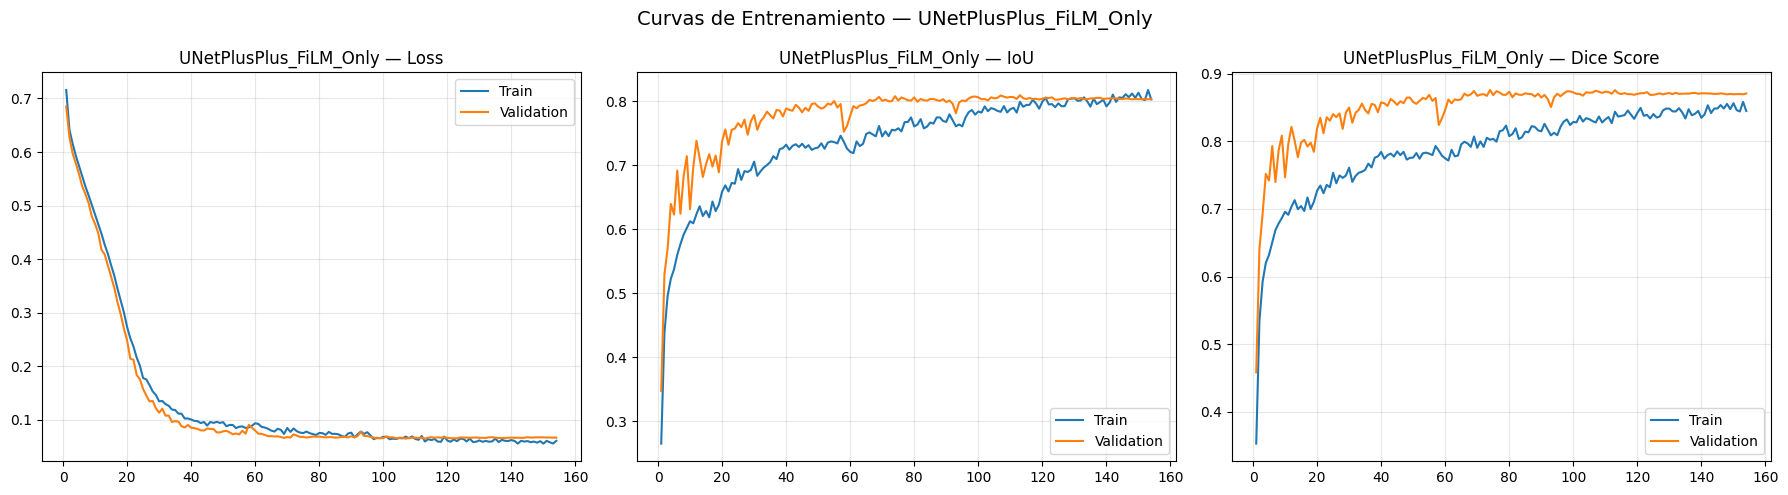


COMPARACIÓN DE ABLACIÓN — UNetPlusPlus_FiLM_Only
  UNetPlusPlus_FiLM_Only Weighted mIoU:           80.65%
  Modelo COMPLETO Weighted mIoU:   80.98%
  Diferencia (Completo - Ablación): +0.33 pp

UNetPlusPlus_FiLM_Only completado.

TODOS LOS MODELOS COMPLETADOS
  Modelos entrenados/cargados: 3


In [19]:

_name = "UNetPlusPlus_FiLM_Only"

_full_wmiou_ref = all_summaries.get('CBAM_UNetPlusPlus_FiLM', {}).get('weighted_miou', 0.8094) * 100

if not _train_ablations:
    print(f" Omitiendo {_name} — el modelo completo no superó el umbral.")
else:
    print("=" * 70)
    print(f"FASE 3: Entrenando ablación — {_name}")
    print("=" * 70)

    if model_already_trained(_name):
        print(f"\n{_name} ya entrenado. Cargando modelo y mostrando métricas...")
        _model = load_model_from_checkpoint(build_unetplusplus_film_only, _name, device)
        _history, _summary, _results_df = load_saved_results(_name)
        _results_df, _summary = save_model_results(
            model_name=_name,
            model=_model,
            history=_history,
            test_loader=test_loader,
            device=device
        )
        plot_training_curves(_history, _name)

        del _model
        clear_memory()

    else:
        clear_memory()
        _model = build_unetplusplus_film_only()

        _model, _history = train_model(
            model=_model,
            model_name=_name,
            train_loader=train_loader,
            val_loader=val_loader,
            device=device,
            hparams=HPARAMS
        )

        _results_df, _summary = save_model_results(
            model_name=_name,
            model=_model,
            history=_history,
            test_loader=test_loader,
            device=device
        )

        visualize_predictions(
            model=_model,
            loader=test_loader,
            device=device,
            model_name=_name,
            n_samples=6
        )

        del _model
        clear_memory()
        print(f"VRAM liberada después de {_name}")

    all_summaries[_name] = _summary
    all_results[_name]   = _results_df
    all_histories[_name] = _history

    _wmiou = _summary['weighted_miou'] * 100
    print(f"\n{'='*70}")
    print(f"COMPARACIÓN DE ABLACIÓN — {_name}")
    print(f"{'='*70}")
    print(f"  {_name} Weighted mIoU:           {_wmiou:.2f}%")
    print(f"  Modelo COMPLETO Weighted mIoU:   {_full_wmiou_ref:.2f}%")
    print(f"  Diferencia (Completo - Ablación): {_full_wmiou_ref - _wmiou:+.2f} pp")


    print(f"\n{_name} completado.")

print("\n" + "=" * 70)
print("TODOS LOS MODELOS COMPLETADOS")
print(f"  Modelos entrenados/cargados: {len(all_summaries)}")
print("=" * 70)


## 6.9 Visualización Best/Worst y Predicciones


VISUALIZANDO MEJORES Y PEORES CASOS — CBAM-UNet++ + FiLM
  CBAM_UNetPlusPlus_FiLM encontrado — Val Dice: 0.8755 (epoch 183)
  CBAM_UNetPlusPlus_FiLM cargado (Val Dice: 0.8755)


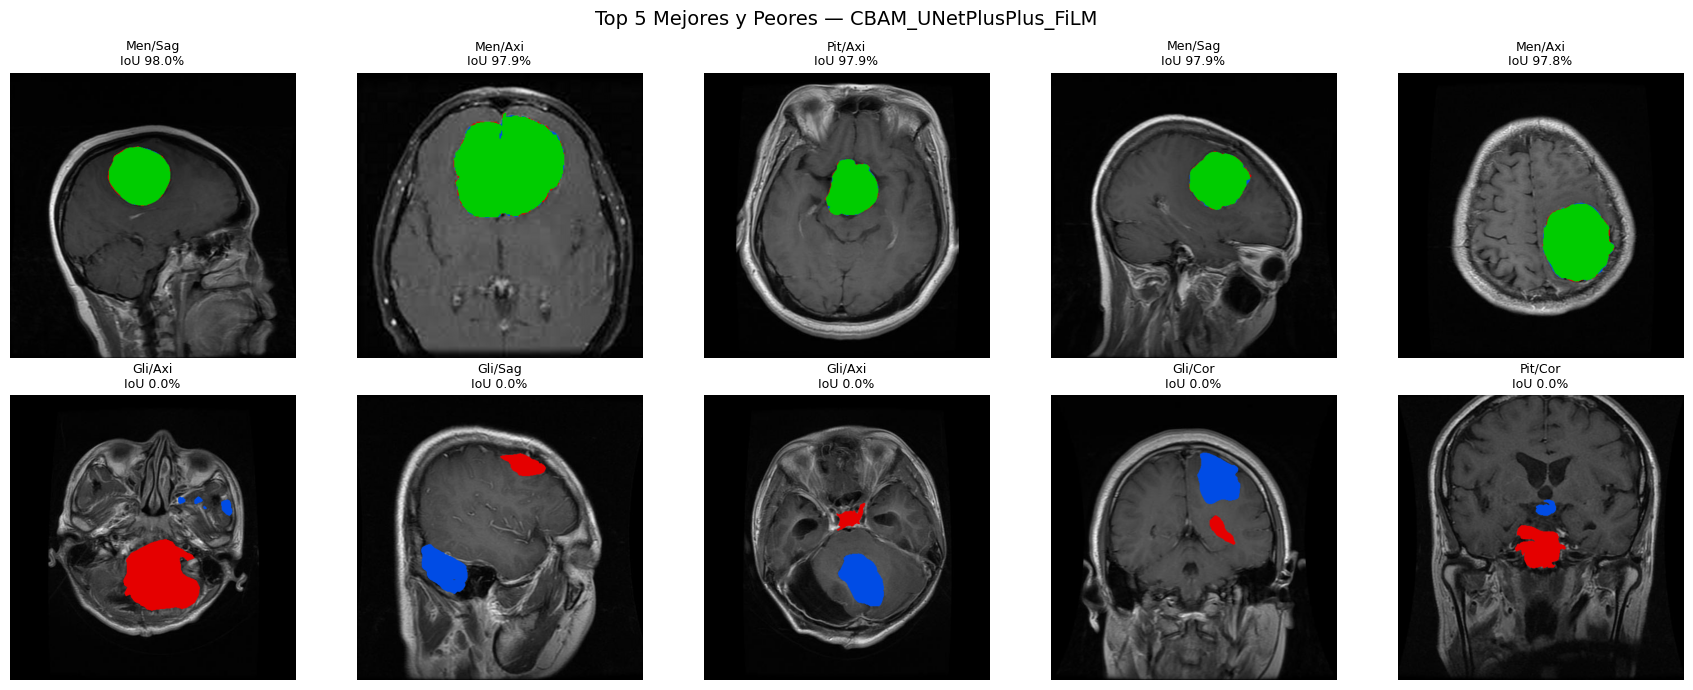

In [20]:
print("\n" + "=" * 70)
print("VISUALIZANDO MEJORES Y PEORES CASOS — CBAM-UNet++ + FiLM")
print("=" * 70)

_name = "CBAM_UNetPlusPlus_FiLM"

if model_already_trained(_name):
    _model = load_model_from_checkpoint(build_cbam_unetplusplus_film, _name, device)
    visualize_best_worst(
        model=_model,
        results_df=all_results[_name],
        df_test_ref=df_test,
        device=device,
        model_name=_name,
        n=5
    )
    del _model
    clear_memory()
else:
    print(f"  {_name} no encontrado. Ejecute primero la Celda 8 de entrenamiento.")





## 6.10 Tabla Comparativa Completa y Análisis Estadístico



In [21]:

BENCH_RESULTS_DIR = "/content/drive/MyDrive/tumores_ceb_proyecto_modelo original_propuesto_1/results_benchmark"
benchmark_names = ['UNet', 'AttentionUNet', 'TransUNet', 'UNetPlusPlus', 'DeepLabV3Plus']

for bm in benchmark_names:
    safe = bm.lower().replace(' ', '_').replace('+', 'plus')
    summ_path = os.path.join(BENCH_RESULTS_DIR, f'{safe}_summary.json')
    if os.path.exists(summ_path) and bm not in all_summaries:
        with open(summ_path, 'r') as f:
            all_summaries[bm] = json.load(f)
        print(f"  Cargado benchmark: {bm}")

display_names = {
    'CBAM_UNetPlusPlus_FiLM':   'CBAM-UNet++ + FiLM (Propuesto)',
    'CBAM_UNetPlusPlus_NoFiLM': 'CBAM-UNet++ sin FiLM (Ablación)',
    'UNetPlusPlus_FiLM_Only':   'UNet++ + FiLM sin CBAM (Ablación)',
    'UNet':         'U-Net (Ours)',
    'AttentionUNet':'Attention U-Net (Ours)',
    'TransUNet':    'TransUNet (Ours)',
    'UNetPlusPlus': 'UNet++ (Ours)',
    'DeepLabV3Plus':'DeepLabV3+ (Ours)',
}

comparison_rows = []
for model_name, summary in all_summaries.items():
    sc = 100 if summary['weighted_miou'] < 1 else 1
    ti = summary['tumor_iou']
    pi = summary['plane_iou']
    comparison_rows.append({
        'Modelo':            display_names.get(model_name, model_name),
        'Weighted mIoU (%)': summary['weighted_miou'] * sc,
        'Dice Global (%)':   summary['global_dice'] * sc,
        'Glioma (%)':        ti.get('Glioma', 0) * sc,
        'Meningioma (%)':    ti.get('Meningioma', 0) * sc,
        'Pituitary (%)':     ti.get('Pituitary', 0) * sc,
        'Axial (%)':         pi.get('Axial', 0) * sc,
        'Coronal (%)':       pi.get('Coronal', 0) * sc,
        'Sagittal (%)':      pi.get('Sagittal', 0) * sc,
        'Tipo':              'Propuesto' if 'FiLM' in model_name or 'CBAM' in model_name else 'Benchmark',
    })

comparison_rows.append({
    'Modelo': 'SaberNet (BRISC) ★',
    'Weighted mIoU (%)': 80.6,
    'Dice Global (%)': None,
    'Glioma (%)': 74.0,
    'Meningioma (%)': 82.4,
    'Pituitary (%)': 84.3,
    'Axial (%)': None,
    'Coronal (%)': None,
    'Sagittal (%)': None,
    'Tipo': 'Referencia',
})

df_compare = pd.DataFrame(comparison_rows).sort_values('Weighted mIoU (%)', ascending=False).reset_index(drop=True)

print("\n" + "=" * 120)
print("TABLA COMPARATIVA — CBAM-UNet++ con FiLM vs BENCHMARKS vs REFERENCIA BRISC")
print("=" * 120)
cols_show = ['Modelo', 'Weighted mIoU (%)', 'Dice Global (%)',
             'Glioma (%)', 'Meningioma (%)', 'Pituitary (%)',
             'Axial (%)', 'Coronal (%)', 'Sagittal (%)']
print(df_compare[cols_show].round(2).to_string(index=False))
print("=" * 120)

df_compare.to_csv(os.path.join(RESULTS_DIR, 'final_comparison.csv'), index=False)
print(f"\n Tabla guardada en: {os.path.join(RESULTS_DIR, 'final_comparison.csv')}")

ablations_present = all(
    name in all_summaries
    for name in ['CBAM_UNetPlusPlus_FiLM', 'CBAM_UNetPlusPlus_NoFiLM', 'UNetPlusPlus_FiLM_Only']
)

if ablations_present:
    print("\n" + "=" * 70)
    print("ANÁLISIS DE APORTE DE COMPONENTES (Ablation Study)")
    print("=" * 70)

    complete  = all_summaries['CBAM_UNetPlusPlus_FiLM']['weighted_miou'] * 100
    no_film   = all_summaries['CBAM_UNetPlusPlus_NoFiLM']['weighted_miou'] * 100
    no_cbam   = all_summaries['UNetPlusPlus_FiLM_Only']['weighted_miou'] * 100

    unet_wmiou = all_summaries.get('UNet', {}).get('weighted_miou', 0.8094) * 100

    print(f"  UNet (baseline):              {unet_wmiou:.2f}%")
    print(f"  CBAM-UNet++ + FiLM (completo): {complete:.2f}%  (Δ baseline = {complete - unet_wmiou:+.2f} pp)")
    print(f"  CBAM-UNet++ sin FiLM:          {no_film:.2f}%  (Δ baseline = {no_film - unet_wmiou:+.2f} pp)")
    print(f"  UNet++ + FiLM sin CBAM:        {no_cbam:.2f}%  (Δ baseline = {no_cbam - unet_wmiou:+.2f} pp)")

    film_contribution = complete - no_film
    cbam_contribution = complete - no_cbam

    print(f"\n  Aporte del FiLM:               {film_contribution:+.2f} pp")
    print(f"  Aporte del CBAM:               {cbam_contribution:+.2f} pp")

    additive_gain = (no_film - unet_wmiou) + (no_cbam - unet_wmiou)
    synergy = (complete - unet_wmiou) - additive_gain
    print(f"\n  Efecto sinérgico (Completo vs suma de partes): Δ = {synergy:+.2f} pp")
    if synergy > 0:
        print(f"     → Los componentes tienen efecto sinérgico positivo.")
    elif synergy < 0:
        print(f"     → Hay interferencia negativa entre componentes.")
    else:
        print(f"     → Los componentes son puramente aditivos.")

if 'CBAM_UNetPlusPlus_FiLM' in all_results and 'UNet' in all_results:
    print("\n" + "=" * 70)
    print("TEST DE WILCOXON — Propuesto vs U-Net (mejor benchmark)")
    print("=" * 70)

    iou_prop = all_results['CBAM_UNetPlusPlus_FiLM']['iou'].values
    iou_unet = all_results['UNet']['iou'].values

    df_prop = all_results['CBAM_UNetPlusPlus_FiLM'][['filename', 'iou']].rename(columns={'iou': 'iou_prop'})
    df_unet = all_results['UNet'][['filename', 'iou']].rename(columns={'iou': 'iou_unet'})
    df_merged = df_prop.merge(df_unet, on='filename')

    stat_w, p_w = wilcoxon(df_merged['iou_prop'].values, df_merged['iou_unet'].values, alternative='two-sided')

    median_prop = np.median(df_merged['iou_prop'].values) * 100
    median_unet = np.median(df_merged['iou_unet'].values) * 100

    print(f"  Mediana IoU — Propuesto: {median_prop:.2f}%")
    print(f"  Mediana IoU — U-Net:     {median_unet:.2f}%")
    print(f"  Estadístico W: {stat_w:.2f}")
    print(f"  p-valor:       {p_w:.6f}")

    if p_w < 0.05:
        print(f"\n  RESULTADO: Diferencia estadísticamente significativa (p < 0.05).")
        if median_prop > median_unet:
            print(f"     → El modelo propuesto supera significativamente a U-Net.")
        else:
            print(f"     → U-Net supera significativamente al modelo propuesto.")
    else:
        print(f"\n  RESULTADO: No se detecta diferencia significativa (p = {p_w:.4f}).")

print("\n Análisis completado.")

  Cargado benchmark: UNet
  Cargado benchmark: AttentionUNet
  Cargado benchmark: TransUNet
  Cargado benchmark: UNetPlusPlus
  Cargado benchmark: DeepLabV3Plus

TABLA COMPARATIVA — CBAM-UNet++ con FiLM vs BENCHMARKS vs REFERENCIA BRISC
                           Modelo  Weighted mIoU (%)  Dice Global (%)  Glioma (%)  Meningioma (%)  Pituitary (%)  Axial (%)  Coronal (%)  Sagittal (%)
   CBAM-UNet++ + FiLM (Propuesto)              80.98            87.58       68.98           90.49          81.43      79.93        80.48         82.88
                     U-Net (Ours)              80.94            87.43       68.70           90.76          81.29      79.65        79.90         83.73
  CBAM-UNet++ sin FiLM (Ablación)              80.92            87.44       68.96           90.83          80.95      79.54        80.21         83.50
                    UNet++ (Ours)              80.85            87.24       68.59           91.14          80.75      79.17        81.15         82.83
UNet++ +

In [22]:
import pandas as pd
import numpy as np
from scipy.stats import wilcoxon

BENCH_RESULTS_DIR = "/content/drive/MyDrive/tumores_ceb_proyecto_modelo original_propuesto_1/results_benchmark"
PROP_RESULTS_DIR  = "/content/drive/MyDrive/tumores_ceb_proyecto_modelo original_propuesto_1/results_proposed_v2"

df_prop = pd.read_csv(os.path.join(PROP_RESULTS_DIR, 'cbam_unetplusplus_film_test_results.csv'))
df_unet = pd.read_csv(os.path.join(BENCH_RESULTS_DIR, 'unet_test_results.csv'))

df_merged = df_prop[['filename', 'iou']].rename(columns={'iou': 'iou_prop'}).merge(
    df_unet[['filename', 'iou']].rename(columns={'iou': 'iou_unet'}),
    on='filename'
)

stat_w, p_w = wilcoxon(df_merged['iou_prop'].values, df_merged['iou_unet'].values, alternative='two-sided')

median_prop = np.median(df_merged['iou_prop'].values) * 100
median_unet = np.median(df_merged['iou_unet'].values) * 100

print("=" * 70)
print("TEST DE WILCOXON — CBAM-UNet++ + FiLM vs U-Net")
print("=" * 70)
print(f"  Muestras pareadas:        {len(df_merged)}")
print(f"  Mediana IoU — Propuesto:  {median_prop:.2f}%")
print(f"  Mediana IoU — U-Net:      {median_unet:.2f}%")
print(f"  Diferencia de medianas:   {median_prop - median_unet:+.2f} pp")
print(f"  Estadístico W:            {stat_w:.2f}")
print(f"  p-valor:                  {p_w:.6f}")
print("─" * 70)

if p_w < 0.05:
    print(f"  RESULTADO: Diferencia estadísticamente significativa (p < 0.05).")
    if median_prop > median_unet:
        print(f"     → El modelo propuesto SUPERA significativamente a U-Net.")
    else:
        print(f"     → U-Net supera significativamente al modelo propuesto.")
else:
    print(f"  RESULTADO: No se detecta diferencia significativa (p = {p_w:.4f}).")
    print(f"     → Las diferencias observadas pueden deberse al azar.")
print("=" * 70)

TEST DE WILCOXON — CBAM-UNet++ + FiLM vs U-Net
  Muestras pareadas:        860
  Mediana IoU — Propuesto:  89.29%
  Mediana IoU — U-Net:      89.53%
  Diferencia de medianas:   -0.24 pp
  Estadístico W:            178238.00
  p-valor:                  0.345290
──────────────────────────────────────────────────────────────────────
  RESULTADO: No se detecta diferencia significativa (p = 0.3453).
     → Las diferencias observadas pueden deberse al azar.
